# Hackathon Team Recommendation — Synthetic Data Generation

Generates CSV training data for a Heterogeneous Graph Transformer (HGT) that recommends team compositions.

## Output tables

| File                    | Description                                                              |
|-------------------------|--------------------------------------------------------------------------|
| `hackathons.csv`        | Hackathon events — topic, team size range                                |
| `participants.csv`      | Participants — experience, position, individual skill set                |
| `team_participants.csv` | All teams with placement labels and `place_rank`                         |
| `skills.csv`            | Skill index                                                              |
| `positions.csv`         | Position index                                                           |


## 1. Config

In [1]:
import sys
import numpy as np
import pandas as pd
import random
import json
import warnings
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta
from entities.skills import ALL_SKILLS, SKILL_TO_IDX, N_SKILLS, POSITION_SKILLS, SUPPLEMENTARY_SKILLS
from entities.positions import ALL_POSITIONS, POSITION_TO_IDX, POSITION_WEIGHTS
from entities.topics import ALL_TOPICS, HACKATHON_TOPICS, TOPIC_POSITION_WEIGHTS

In [2]:
sys.path.append(str(Path().resolve().parent))

In [3]:
CONFIG = {
    "n_hackathons": 300,
    "teams_per_hackathon_min": 20,
    "teams_per_hackathon_max": 50,
    "team_size_min": 2,
    "team_size_max": 6,
    "random_seed": 42,
}

In [4]:
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

In [5]:
OUTPUT_DIR = Path("output/data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Generation Helpers

Functions for experience sampling, skill sampling, and performance scoring. The performance score is an internal value used to rank teams after generation.


In [6]:
PLACE_RANK = {"1st": 1, "2nd": 2, "3rd": 3, "participant": 4}

POSITIONS = ALL_POSITIONS
TOPICS = ALL_TOPICS

_SUPP_SET = set(SUPPLEMENTARY_SKILLS)

In [7]:
def _multi_hot(skills: list[str]) -> list[int]:
    vec = [0] * N_SKILLS
    for s in skills:
        if s in SKILL_TO_IDX:
            vec[SKILL_TO_IDX[s]] = 1
    return vec

In [8]:
def _exp_years() -> float:
    return round(float(np.random.exponential(scale=2.5)), 1)


def _exp_level(years: float) -> str:
    if years < 1:  return "beginner"
    if years < 3:  return "junior"
    if years < 6:  return "mid"
    if years < 10: return "senior"
    return "expert"

In [9]:
def _skill_count(years: float) -> int:
    if years < 1:  return random.randint(2, 4)
    if years < 3:  return random.randint(3, 6)
    if years < 6:  return random.randint(4, 7)
    return random.randint(5, 8)


def _skill_coverage(team_skills: set, required: list) -> float:
    if not required:
        return 0.0
    return len(set(required) & team_skills) / len(required)

In [10]:
def _weighted_position() -> str:
    return random.choices(ALL_POSITIONS, weights=POSITION_WEIGHTS, k=1)[0]


def _position_diversity(positions: list[str]) -> float:
    return len(set(positions)) / len(positions)

In [11]:
def _participant_skills(
        years: float,
        position: str | None = None,
        team_skills: set | None = None,
        topic_skills: list[str] | None = None,
        required_skills: list[str] | None = None,
) -> list[str]:
    n = min(_skill_count(years), N_SKILLS)
    pos_set = set(POSITION_SKILLS.get(position, ALL_SKILLS)) if position else set(ALL_SKILLS)
    topic_set = set(topic_skills) if topic_skills else set()
    covered = set(team_skills) if team_skills else set()
    required_set = set(required_skills) if required_skills else topic_set

    req_coverage = (
        len(covered & required_set) / len(required_set)
        if required_set else 0.5
    )

    t1 = [s for s in ALL_SKILLS if s in pos_set and s in topic_set and s not in _SUPP_SET]
    t2 = [s for s in ALL_SKILLS if s not in pos_set and s in topic_set and s not in _SUPP_SET]
    t3 = [s for s in ALL_SKILLS if s in pos_set and s not in topic_set and s not in _SUPP_SET]
    t_s = [s for s in SUPPLEMENTARY_SKILLS if s in pos_set]
    t4 = [s for s in ALL_SKILLS if s not in pos_set and s not in topic_set and s not in _SUPP_SET]

    if topic_set:
        t1_budget = round(n * (0.55 - 0.25 * req_coverage))
        t2_budget = round(n * (0.20 - 0.05 * req_coverage))
        t3_budget = round(n * (0.05 + 0.25 * req_coverage))
        ts_budget = round(n * 0.25 * req_coverage)
        budgets = [
            (t1, t1_budget),
            (t2, t2_budget),
            (t3, t3_budget),
            (t_s, ts_budget),
            (t4, n),
        ]
    else:
        budgets = [
            (t3, round(n * (0.60 + 0.20 * req_coverage))),
            (t_s, round(n * 0.20 * req_coverage)),
            (t4, n),
        ]

    chosen: list[str] = []
    for pool, budget in budgets:
        if len(chosen) >= n:
            break
        new_skills = [s for s in pool if s not in covered and s not in chosen]
        dup_skills = [s for s in pool if s in covered and s not in chosen]
        take = min(budget, n - len(chosen))
        take_new = min(round(take * 0.5), len(new_skills))
        take_dup = min(take - take_new, len(dup_skills))
        if take_new > 0:
            chosen += random.sample(new_skills, take_new)
        if take_dup > 0:
            chosen += random.sample(dup_skills, take_dup)
        leftover = take - take_new - take_dup
        if leftover > 0:
            extra_new = [s for s in new_skills if s not in chosen]
            extra_dup = [s for s in dup_skills if s not in chosen]
            fill = extra_new + extra_dup
            chosen += random.sample(fill, min(leftover, len(fill)))

    return chosen[:n]

### Place assignment logic

In [12]:
def _performance_score(
        team_skills: set,
        required: list,
        bonus: list,
        avg_exp: float,
        team_size: int,
        ideal_size: int,
        positions: list[str],
        member_skills: list[list[str]],
) -> float:
    skill_match = _skill_coverage(team_skills, required)
    pos_diversity = _position_diversity(positions)

    total_slots = sum(len(s) for s in member_skills)
    skill_diversity = len(team_skills) / total_slots if total_slots > 0 else 0.0

    exp_score = float(np.tanh(avg_exp / 3.0))
    size_fit = 1.0 - abs(team_size - ideal_size) / max(ideal_size, 1)
    noise = float(np.random.beta(2, 5))

    bonus_match = _skill_coverage(team_skills, bonus) if bonus else 0.0
    bonus_gate = max(0.0, (skill_match - 0.40) / 0.60)

    supp_count = len(team_skills & _SUPP_SET)
    supp_match = supp_count / len(SUPPLEMENTARY_SKILLS)
    supp_gate = max(0.0, (skill_match - 0.50) / 0.50)

    score = (
            0.35 * skill_match
            + 0.10 * bonus_match * bonus_gate
            + 0.10 * supp_match * supp_gate
            + 0.15 * exp_score
            + 0.12 * pos_diversity
            + 0.12 * skill_diversity
            + 0.04 * size_fit
            + 0.02 * noise
    )
    return round(min(score, 1.0), 4)


In [13]:
def _assign_places(scores: list[float]) -> list[str]:
    indexed = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
    places = ["participant"] * len(scores)
    for rank, (orig_idx, _) in enumerate(indexed):
        if rank == 0:
            places[orig_idx] = "1st"
        elif rank == 1:
            places[orig_idx] = "2nd"
        elif rank == 2:
            places[orig_idx] = "3rd"
    return places


## 3. Data Generation

In [14]:
HACKS_PER_TOPIC = CONFIG["n_hackathons"] // len(TOPICS)

hackathon_rows = []
hackathon_id = 0

for topic in TOPICS:
    for _ in range(HACKS_PER_TOPIC):
        min_sz = random.choice([2, 3])
        max_sz = random.choice([4, 5, 6])

        hackathon_rows.append({
            "hackathon_id": hackathon_id,
            "topic": topic,
            "min_team_size": min_sz,
            "max_team_size": max_sz,
        })
        hackathon_id += 1

In [15]:
df_hackathons = pd.DataFrame(hackathon_rows)
print(f"Generated {len(df_hackathons)} hackathons")
df_hackathons.head(3)

Generated 300 hackathons


,hackathon_id,topic,min_team_size,max_team_size
0,0,AI / Machine Learning,2,4
1,1,AI / Machine Learning,3,4
2,2,AI / Machine Learning,2,4


In [16]:
participant_rows_dict: dict[int, dict] = {}

team_placements: dict[int, dict] = {}
team_part_rows: list[dict] = []

team_id = 0
next_pid = 0

for _, hack in df_hackathons.iterrows():
    n_teams = random.randint(CONFIG["teams_per_hackathon_min"],
                             CONFIG["teams_per_hackathon_max"])
    required = HACKATHON_TOPICS[hack["topic"]]["required"]
    bonus = HACKATHON_TOPICS[hack["topic"]]["bonus"]
    topic_skills = required + bonus
    ideal_size = (hack["min_team_size"] + hack["max_team_size"]) // 2
    topic_pos_w = TOPIC_POSITION_WEIGHTS[hack["topic"]]

    hack_teams: list[dict] = []

    for _ in range(n_teams):
        size = random.randint(hack["min_team_size"], hack["max_team_size"])
        team_skills: set[str] = set()
        team_positions: list[str] = []
        team_pos_set: set[str] = set()
        exp_years_list: list[float] = []
        member_skills_list: list[list[str]] = []

        for role_idx in range(size):
            exp = _exp_years()
            unused_pos = [pos for pos in ALL_POSITIONS if pos not in team_pos_set]
            if unused_pos:
                unused_w = [topic_pos_w[ALL_POSITIONS.index(pos)] for pos in unused_pos]
                position = random.choices(unused_pos, weights=unused_w, k=1)[0]
            else:
                position = random.choices(ALL_POSITIONS, weights=topic_pos_w, k=1)[0]
            skls = _participant_skills(
                exp, position, team_skills, topic_skills,
                required_skills=required,
            )
            vec = json.dumps(_multi_hot(skls))
            pid = next_pid
            next_pid += 1

            participant_rows_dict[pid] = {
                "participant_id": pid,
                "experience_years": exp,
                "experience_level": _exp_level(exp),
                "position": position,
                "skills": json.dumps(skls),
                "skills_vector": vec,
            }

            team_part_rows.append({
                "team_id": team_id,
                "participant_id": pid,
                "hackathon_id": int(hack["hackathon_id"]),
                "role": "leader" if role_idx == 0 else "member",
            })

            team_skills.update(skls)
            team_positions.append(position)
            team_pos_set.add(position)
            exp_years_list.append(exp)
            member_skills_list.append(skls)

        avg_exp = float(np.mean(exp_years_list))
        perf = _performance_score(
            team_skills, required, bonus, avg_exp,
            size, ideal_size, team_positions, member_skills_list,
        )
        hack_teams.append({"team_id": team_id, "perf_score": perf})
        team_id += 1

    scores = [t["perf_score"] for t in hack_teams]
    places = _assign_places(scores)
    for t, place in zip(hack_teams, places):
        team_placements[t["team_id"]] = {
            "place": place,
            "place_rank": PLACE_RANK[place],
            "perf_score": t["perf_score"],
        }

In [17]:
df_participants = pd.DataFrame(list(participant_rows_dict.values()))
df_team_part = pd.DataFrame(team_part_rows)

df_team_part["place"] = df_team_part["team_id"].map(lambda tid: team_placements[tid]["place"])
df_team_part["place_rank"] = df_team_part["team_id"].map(lambda tid: team_placements[tid]["place_rank"])
df_team_part["perf_score"] = df_team_part["team_id"].map(lambda tid: team_placements[tid]["perf_score"])

df_unique_teams = df_team_part.drop_duplicates("team_id")

In [18]:
df_skills = pd.DataFrame([
    {"skill_id": idx, "skill_name": name}
    for name, idx in SKILL_TO_IDX.items()
])

df_positions = pd.DataFrame([
    {"position_id": idx, "position_name": name}
    for name, idx in POSITION_TO_IDX.items()
])

## 4. Dataset Statistics


In [19]:
print(f"{"Hackathons":20s} {len(df_hackathons):,}")
print(f"{"Total teams":20s} {df_unique_teams['team_id'].nunique():,}")
print(f"{"Unique participants":20s} {len(df_participants):,}")
print(f"{"Unique skills":20s} {N_SKILLS}")

Hackathons           300
Total teams          10,213
Unique participants  38,471
Unique skills        85


In [20]:
print("Placement distribution:")
for place, cnt in df_unique_teams["place"].value_counts().items():
    pct = cnt / len(df_unique_teams) * 100
    print(f"\t{place:<12} {cnt:>7,} ({pct:4.1f}%)")
    df_unique_teams = df_team_part.drop_duplicates("team_id")

Placement distribution:
	participant    9,313 (91.2%)
	2nd              300 ( 2.9%)
	3rd              300 ( 2.9%)
	1st              300 ( 2.9%)


In [21]:
print("Team size distribution")
for size, cnt in df_team_part.groupby("team_id").size().value_counts().sort_index().items():
    pct = cnt / len(df_unique_teams) * 100
    print(f"\tsize {size}: {cnt:>5,} ({pct:4.1f}%)")

Team size distribution
	size 2: 1,288 (12.6%)
	size 3: 3,263 (31.9%)
	size 4: 3,079 (30.1%)
	size 5: 1,708 (16.7%)
	size 6:   875 ( 8.6%)


In [22]:
print("Experience levels")
for lvl, cnt in df_participants["experience_level"].value_counts().items():
    pct = cnt / len(df_participants) * 100
    print(f"\t{lvl:<8} {cnt:>6,} ({pct:4.1f}%)")

Experience levels
	junior   14,485 (37.7%)
	beginner 12,145 (31.6%)
	mid       8,324 (21.6%)
	senior    2,803 ( 7.3%)
	expert      714 ( 1.9%)


In [23]:
print("Positions")
for pos, cnt in df_participants["position"].value_counts().items():
    pct = cnt / len(df_participants) * 100
    print(f"\t{pos:<25} {cnt:>5,} ({pct:4.1f}%)")

Positions
	UI/UX Designer            3,334 ( 8.7%)
	Full Stack Developer      3,312 ( 8.6%)
	Backend Developer         3,269 ( 8.5%)
	DevOps Engineer           2,881 ( 7.5%)
	Product Manager           2,798 ( 7.3%)
	Machine Learning Engineer 2,721 ( 7.1%)
	Frontend Developer        2,637 ( 6.9%)
	AR/VR Developer           2,452 ( 6.4%)
	Data Scientist            2,388 ( 6.2%)
	Game Developer            2,315 ( 6.0%)
	Security Engineer         2,217 ( 5.8%)
	Mobile Developer          2,156 ( 5.6%)
	Embedded / IoT Engineer   2,080 ( 5.4%)
	QA Engineer               1,975 ( 5.1%)
	Blockchain Developer      1,936 ( 5.0%)


In [24]:
topic_team_counts = (
    df_unique_teams.merge(df_hackathons[["hackathon_id", "topic"]], on="hackathon_id")
    .groupby("topic")["team_id"].count()
    .sort_values(ascending=False)
)
total = topic_team_counts.sum()

print("Topics")
for topic, cnt in topic_team_counts.items():
    pct = cnt / total * 100
    print(f"\t{topic:<21} {cnt:>5,} teams ({pct:4.1f}%)")

Topics
	FinTech               1,075 teams (10.5%)
	AI / Machine Learning 1,071 teams (10.5%)
	Web Development       1,056 teams (10.3%)
	HealthTech            1,042 teams (10.2%)
	IoT & Embedded        1,040 teams (10.2%)
	Game Development      1,024 teams (10.0%)
	Mobile Development      999 teams ( 9.8%)
	Cybersecurity           997 teams ( 9.8%)
	AR / VR                 970 teams ( 9.5%)
	Blockchain / Web3       939 teams ( 9.2%)


### Visualization

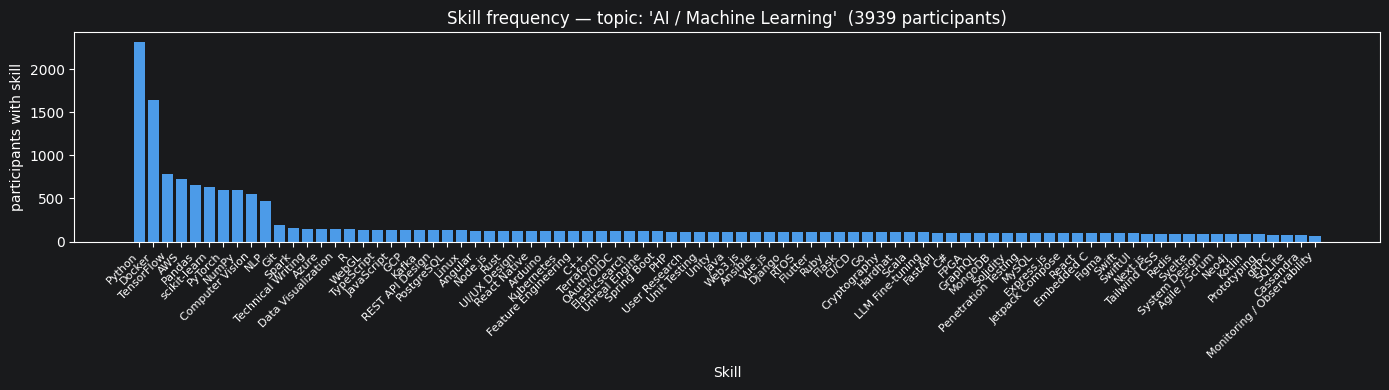

In [25]:
topic0 = ALL_TOPICS[0]
hack_ids_topic0 = set(df_hackathons[df_hackathons["topic"] == topic0]["hackathon_id"])
part_ids_topic0 = set(df_team_part[df_team_part["hackathon_id"].isin(hack_ids_topic0)]["participant_id"])
topic0_parts = df_participants[df_participants["participant_id"].isin(part_ids_topic0)]

skill_counts = topic0_parts["skills_vector"].apply(lambda v: (np.array(json.loads(v)) > 0).astype(int)).sum()
skill_names = [row["skill_name"] for _, row in df_skills.sort_values("skill_id").iterrows()]
order = np.argsort(skill_counts)[::-1]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar([skill_names[i] for i in order], skill_counts[order], color="#4C9BE8")
ax.set_title(f"Skill frequency — topic: '{topic0}'  ({len(topic0_parts)} participants)")
ax.set_xlabel("Skill")
ax.set_ylabel("participants with skill")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

## 5. Save to CSV

In [26]:
df_hackathons.to_csv(OUTPUT_DIR / "hackathons.csv", index=False)
df_participants.to_csv(OUTPUT_DIR / "participants.csv", index=False)
df_team_part.to_csv(OUTPUT_DIR / "team_participants.csv", index=False)
df_skills.to_csv(OUTPUT_DIR / "skills.csv", index=False)
df_positions.to_csv(OUTPUT_DIR / "positions.csv", index=False)

In [27]:
print("\nSaved to output/")
for fname in ["hackathons.csv", "participants.csv", "team_participants.csv", "skills.csv", "positions.csv"]:
    path = OUTPUT_DIR / fname
    print(f"\t{fname:<28} {path.stat().st_size // 1024:>5} KB")


Saved to output/
	hackathons.csv                   6 KB
	participants.csv             13442 KB
	team_participants.csv         1593 KB
	skills.csv                       1 KB
	positions.csv                    0 KB
